46V-03
The file has already been processed.
43V-02
The file has already been processed.
50V-01
The file has already been processed.
45V-01
The file has already been processed.
47V-04
The file has already been processed.
46V-02
The file has already been processed.
49V-01
The file has already been processed.
51V-04
The file has already been processed.
45V-02
The file has already been processed.
50V-02
The file has already been processed.
43V-01
The file has already been processed.
49V-02
The file has already been processed.
45V-03
The file has already been processed.
47V-02
The file has already been processed.
46V-04
The file has already been processed.
44V-01
The file has already been processed.
43V-04
The file has already been processed.
47V-03
The file has already been processed.
51V-01
The file has already been processed.
49V-04
The file has already been processed.
44V-03
The file has already been processed.
48V-02
['18', '23', '49', '032', '209', '736']
Error: line contains NUL
51V-

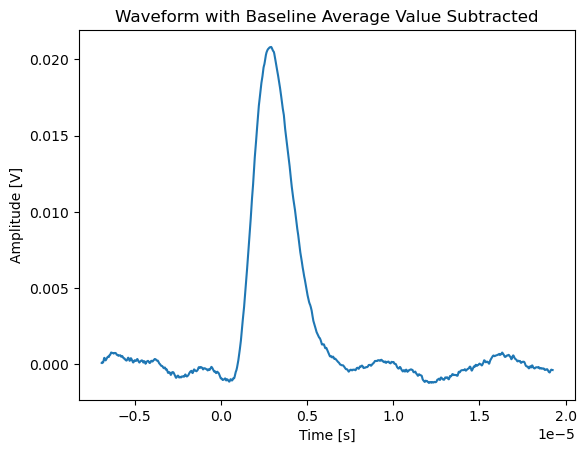

[-0.012455534, -0.012440097, -0.01243392, -0.012437005, -0.012449358, -0.012464795, -0.012474064, -0.012483325, -0.012489501, -0.012501854, -0.012517292, -0.012535822, -0.012551259, -0.01256052, -0.01256052, -0.012557436, -0.012557436, -0.012563612, -0.012575965, -0.012585226, -0.012585226, -0.012572873, -0.012551259, -0.012529645, -0.012501854, -0.012486409, -0.012477148, -0.012470972, -0.012467887, -0.012455534, -0.01243392, -0.012409214, -0.0123876, -0.012375247, -0.012378331, -0.012393776, -0.012412306, -0.012427744, -0.012427744, -0.01241539, -0.012396861, -0.012375247, -0.012356717, -0.012347456, -0.012353633, -0.01236907, -0.012390684, -0.012403037, -0.012403037, -0.0123876, -0.012372162, -0.012359809, -0.012350541, -0.012353633, -0.012362894, -0.012375247, -0.012390684, -0.012403037, -0.01241539, -0.01243392, -0.012467887, -0.012508031, -0.012551259, -0.012575965, -0.012575965, -0.012557436, -0.012526553, -0.012495678, -0.012470972, -0.012449358, -0.012443181, -0.012443181, -0.

In [ ]:
'''
This program reads the .csv and .wfm.csv files from the oscilloscope and stores the waveforms in a .npy file.
The .npy file is a numpy array that can be read by the analysis.py program.

Store the .csv and .Wfm.csv files in a directory called 'SiPM02' in the same directory as this program.
The waveforms will be stored in a directory called 'waveforms' in the same directory as this program.

Sometimes scope/SiPM02 data is saved with timestamps in the data file, and sometimes it is not.
Select timestamps = True if the data file has timestamps, and select timestamps = False if the data file does not have timestamps.
'''


import os
import csv
import matplotlib.pyplot as plt
import datetime
import numpy as np

# Function to read the data and store the parameters in a dictionary and return the waveforms in a list
def read_file(file_name):
    # Read the .csv file with run parameters
    csv_file_path = file_name+'.csv'
    parameters = {}

    # Store the parameters in a dictionary
    with open(csv_file_path, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            if row[0][0:10] == 'Timestamp:':
                parameter, *values = row[0].split(':')
                val2 = values[1].split(' ')
                val3 = row[1][:-3].split('.')
                values = [values[0],val2[0],val2[1],val3[0],val3[1],val3[2]]
                parameters[parameter] = values
            else:
                parameter, *values = row[0].split(':')
                parameters[parameter] = values

    # Check whether timestamps are included in the data file
    timestamps = parameters['TimestampState'][0]
    # The number of samples in each waveform is SignalHardwareRecordLength
    wfmlen = int(parameters['SignalHardwareRecordLength'][0])
    rectime = parameters['Timestamp']
    print(rectime)
    # Read the .wfm.csv file and store the waveforms
    wfm_csv_file_path = file_name+'.Wfm.csv'
    waveform_data = []
    waveforms = []
    
    # Read the .wfm.csv file and store the waveform data in a list
    with open(wfm_csv_file_path, 'r') as file:
        reader = csv.reader(file)
        relative_time = []
        # Iterate through the rows in the .wfm.csv file
        if timestamps == 'On':   
            for row in reader:
                if len(waveform_data) == 0:
                    relative_time.append(float(row[0]))  # Assuming the relative timestamp is in the first column
                    waveform_data.append(-1)  # Add a placeholder for the relative timestamp
                else:
                    waveform_data.append(float(row[0]))  # Assuming the waveform data starts from the second column
                # Store the waveform data in an array     
                if len(waveform_data) == (wfmlen+1):
                    waveforms.append(waveform_data[1:]) # Here we just exclude the waveform_data[0]
                    waveform_data = []     

        if timestamps == 'Off':
            # Iterate through the rows in the .wfm.csv file
            for row in reader:
                waveform_data.append(float(row[0]))  # Assuming the waveform data is in the first column
                # Store the waveform data in an array
                if len(waveform_data) == wfmlen:
                    waveforms.append(waveform_data)
                    waveform_data = []

    return waveforms, parameters, relative_time

# Function to access waveform arrays
def get_waveform(waveforms,index):
    return np.array(waveforms[index]) 

# Function to get the time array for each waveform
def get_time(parameters):
    # The start time for each waveform is HardwareXStart
    xstart = float(parameters['HardwareXStart'][0])
    # The end time for each waveform is HardwareXStop
    xstop = float(parameters['HardwareXStop'][0])
    # The time between each sample is SignalResolution
    xinc = float(parameters['SignalResolution'][0])
    if parameters['TimestampState'][0] == 'On':
        # The time array for each waveform is
        time = np.arange(xstart, xstop, xinc)
    else:
        # The time array for each waveform is
        time = np.arange(xstart, xstop, xinc)
    return time, xinc

# Function to find the baseline of each waveform
def find_baseline(waveform,time):
    print(len(waveform),len(time))
    residuals = np.abs(waveform - np.mean(waveform))
    threshold = np.percentile(residuals, 80)
    baseline = waveform[residuals <= threshold]
    btime = time[residuals <= threshold]
    return baseline, btime

# Function to integrate the waveform
def integrate_waveform(waveform, tinc):
    # Integrate the waveform
    integral = np.sum(waveform)*tinc
    return integral

# Function to fix the baseline of each waveform
def fix_baseline(waveforms,parameters):
    # Plot the waveform, mean, and standard error for each iteration
    charge = []
    for i in range(0, len(waveforms)):
        waveform = get_waveform(waveforms,i)
        time, tinc = get_time(parameters)
        baselines = [waveform]
        btimes = [time]
        means = [np.mean(waveform)]
        std_errors = [np.std(waveform) / np.sqrt(len(waveform))]
        # Iterate through the waveform until the baseline stabilizes
        for _ in range(2):
            baseline, btime = find_baseline(waveform,time)
            baselines.append(baseline)
            btimes.append(btime)
            means.append(np.mean(baseline))
            std_errors.append(np.std(baseline) / np.sqrt(len(baseline)))
            waveform = baseline
            time = btime
        # Subtract the baseline average value from the waveform
        waveform = get_waveform(waveforms,i) - means[-1]
        charge.append(integrate_waveform(waveform, tinc))
        waveforms[i] = waveform
        time, tinc = get_time(parameters)
        # Plot the baseline corrected waveform
        if __name__ == '__main__':
            # Plot the wavefore every 1000 iterations
            if i % 1000 == 0:
                plt.figure()
                plt.plot(time, waveform)
                plt.xlabel('Time [s]')
                plt.ylabel('Amplitude [V]')
                plt.title('Waveform with Baseline Average Value Subtracted')
                plt.show()    
        return waveforms, np.array(charge)
    
# Create a log file to store the version of the program and the parameters used
def create_log_file(file_name, version):
    # Create a log file
    log_file_path = file_name+'/version.log'
    # Write the version of the program to the log file
    with open(log_file_path, 'w') as file:
        file.write('Version: %s\n' % version)
    # Write the date and time the program was run to the log file
    with open(log_file_path, 'a') as file:
        file.write('Date and Time: %s\n' % datetime.datetime.now())

# Function to run the program
def main(file_name,data_dir,save_dir):
    # Version of the program
    version = '1.3'
    run = True
    indir = os.path.join(data_dir,file_name)
    outdir = os.path.join(save_dir,file_name)
    # Make a new directory for the .npy files
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    # Check if the file has been processed
    
    if os.path.exists(outdir+'/version.log'):
        with open(outdir+'/version.log', 'r') as file:
            lines = file.readlines()
            # Check if the version of the program is the same
            if lines[0].split()[1] == version:
                print('The file has already been processed.')
                run = False
    
    # Run the program if the file has not been processed
    if run:
        # Run the program
       
        waveforms, parameters, relative_time = read_file(indir)
        time, tinc = get_time(parameters)
        waveforms, charge = fix_baseline(waveforms,parameters) # this gives an average baseline value subtracted waveform
        
        # Save the waveforms to a .npy file and add the parameters for the time array xstart, xstop, and xinc to the .npy file
        np.save('%s/waveforms.npy'%outdir, waveforms)
        np.save('%s/parameters.npy'%outdir, parameters)
        np.save('%s/time.npy'%outdir, time)
        np.save('%s/ttime.npy'%outdir, relative_time)
        # Save the version of the program to a log file
        create_log_file(outdir, version)

if __name__ == '__main__':
    # Data directory
    data_dir = 'SiPM02'
    # Save directory
    save_dir = 'waveforms'
    # List of file names in the directory
    file_names = os.listdir(data_dir)
    # Iterate through the file names
    for file_name in file_names:
        # Check if the file is a .Wfm.csv file
        if file_name.endswith('.Wfm.csv'):
            # Run the program
            print(file_name[:-8])
            try:
                main(file_name[:-8],data_dir,save_dir) # names files excluding  '.wfm.csv'
            except csv.Error as e:
                print ("Error: line contains NUL") # this assumes all files have the same error, might have to verify this
                continue
            
            